In [26]:
# ============================================================
# SHCHERBINA-STYLE UPPER-2-LAYER ANALYSIS
# ============================================================

from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Opening glued state diagnostics...
time_dim          : T
z_dim             : Zmd000002
n time steps      : 28
n vertical levels : 2
LAYER_MODE        : surface_layer
TOP_LEVELS        : [0]
selected snapshot : index 20 -> t = 10.0 days
square grid       : 4 x 4


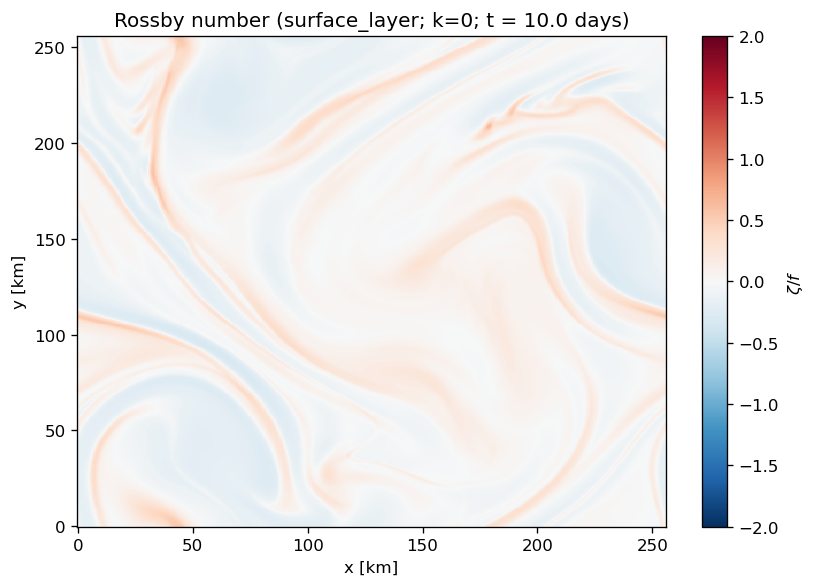

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\rossby_map_surface_layer_t0020.png


<Figure size 840x600 with 0 Axes>

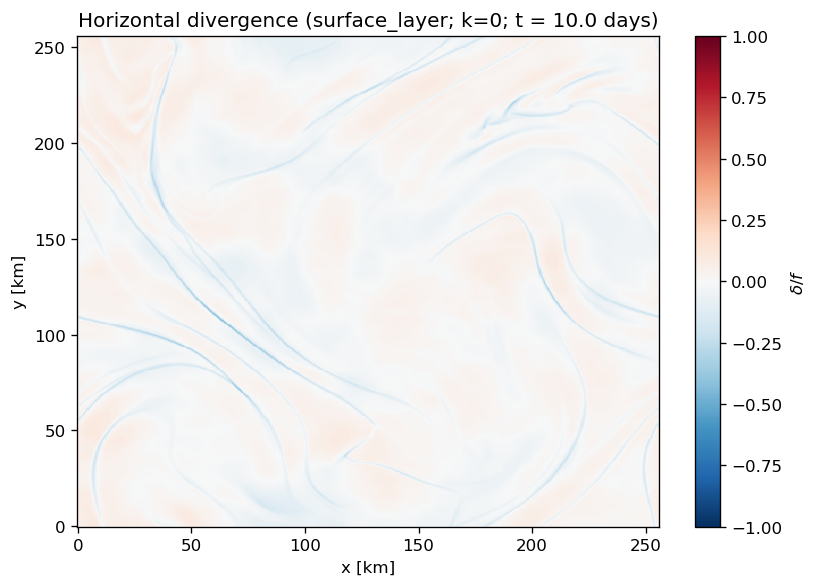

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\divergence_map_surface_layer_t0020.png


<Figure size 840x600 with 0 Axes>

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\pdfs_surface_layer_t0020.png


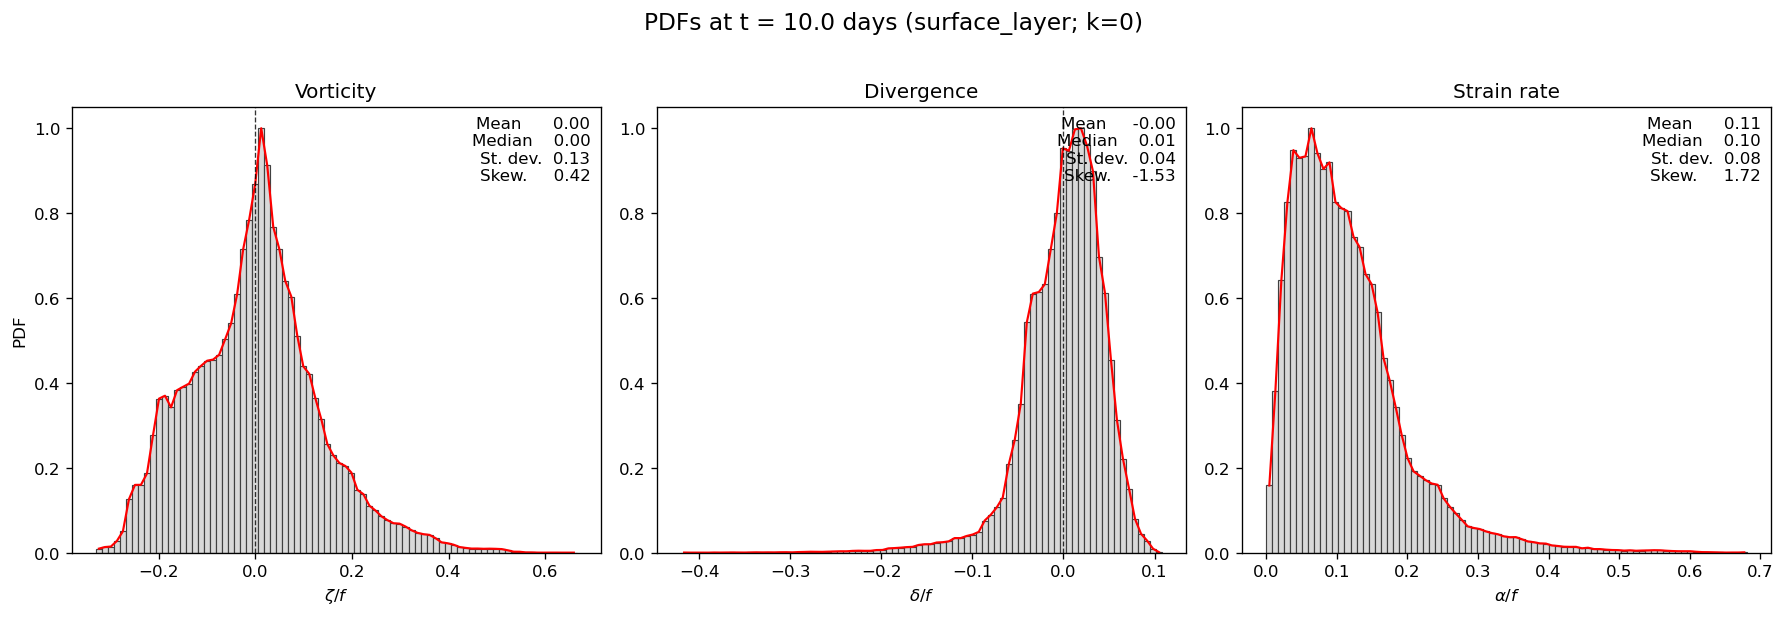

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\jpdf_vorticity_strain_surface_layer_t0020.png


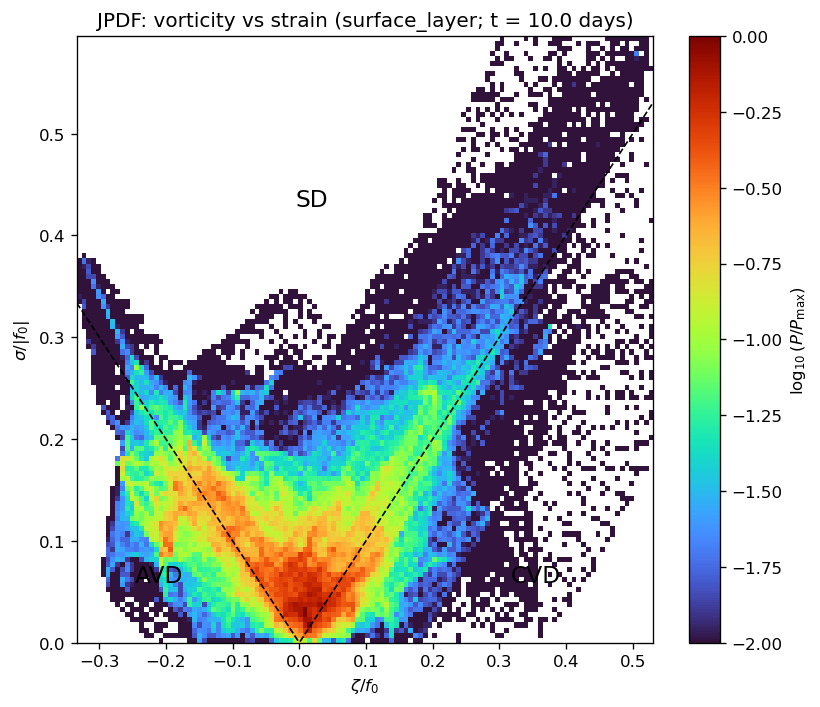

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\jpdf_vorticity_divergence_surface_layer_t0020.png


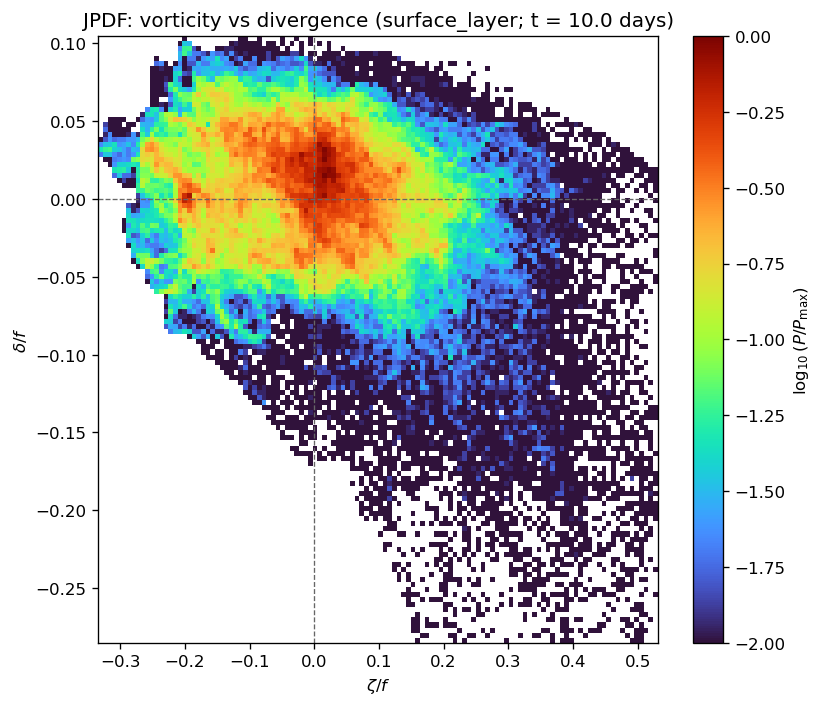

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\rossby_squares_surface_layer_t0020.png


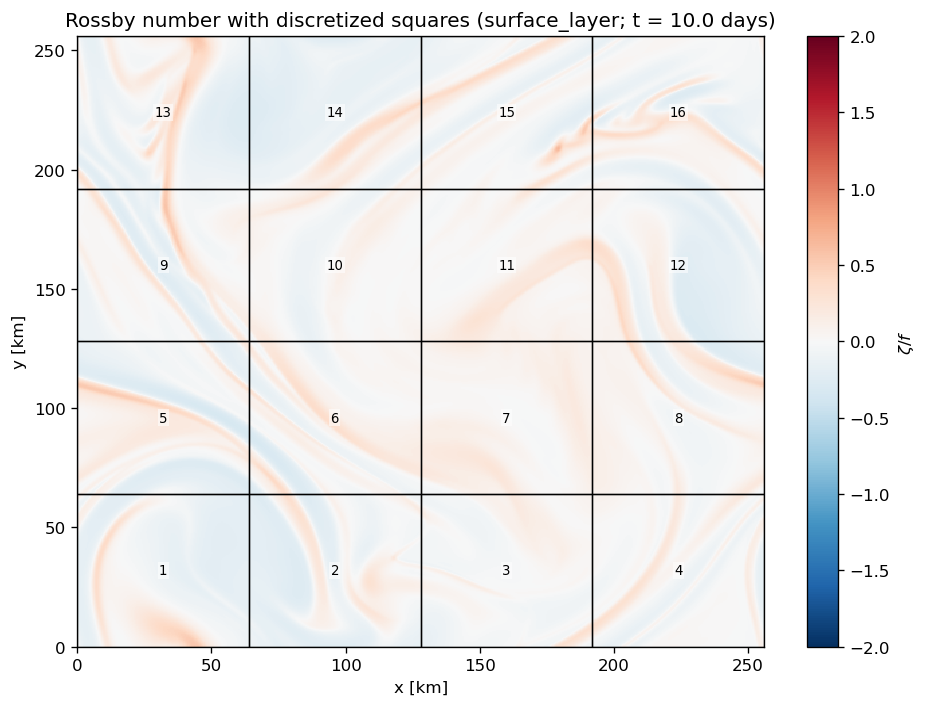

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_41624\516175092.py:540: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_squares_total)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\pro_per_square_timeseries_surface_layer_4x4.png


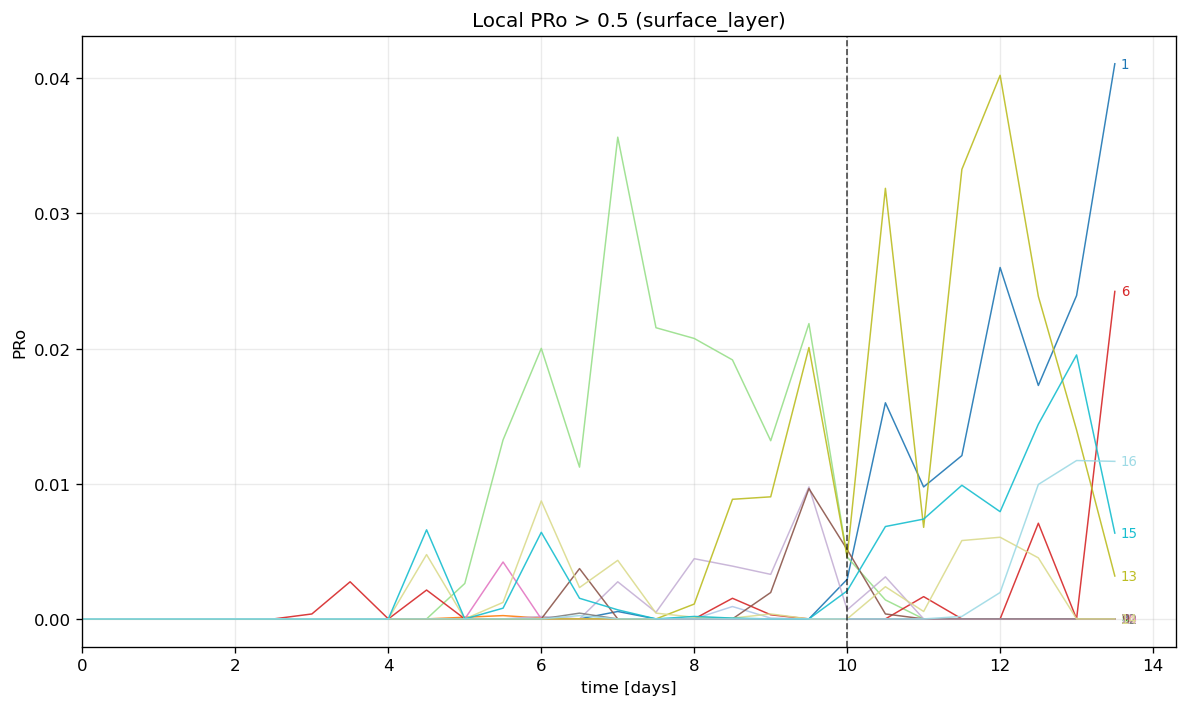

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_boyd_smag_high_diff_low_diags\pro_per_square_surface_layer_4x4.csv

Notebook variables now available:
  ds
  ro, div_f, strain_f
  H_vs, H_vs_log
  H_vd, H_vd_log
  squares
  square_metrics_df
  square_pro_wide


In [33]:
# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

NB_DIR = Path.cwd()

DATA_FILE = (NB_DIR / "../data/input/state_diag.0000000000.glob.nc").resolve()
UTILS_PATH = (NB_DIR / "../scripts").resolve()
MODULE_NAME = "shcherbina_utils"

OUT_DIR = (NB_DIR / "../results/run_boyd_smag_high_diff_low_diags").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find glued state file at:\n{DATA_FILE}")

# save toggle
SAVE = True

DX = 500.0
DY = 500.0
F0 = 8.0e-5

# ---- choose only this timestep ----
SELECTED_TIME_INDEX = 20
DAY_PER_INDEX = 0.5

# ---- choose layer mode ----
# "surface_layer"      -> use k=0 only
# "upper_2_layers"     -> diagnose each of k=0,1 then average the diagnostics
LAYER_MODE = "surface_layer"

if LAYER_MODE == "surface_layer":
    TOP_LEVELS = [0]
    LAYER_LABEL = "k=0"
elif LAYER_MODE == "upper_2_layers":
    TOP_LEVELS = [0, 1]
    LAYER_LABEL = "k=0,1"
else:
    raise ValueError("LAYER_MODE must be 'surface_layer' or 'upper_2_layers'")

# ---- domain subdivision for local PRo ----
N_SQUARES_X = 4
N_SQUARES_Y = 4

# histogram / JPDF settings
nbins_pdf = 80
nbins_jpdf = 120

# Rossby number threshold
PRo_threshold = 0.5

# style
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 120

# ------------------------------------------------------------
# IMPORT HELPERS
# ------------------------------------------------------------
if str(UTILS_PATH) not in sys.path:
    sys.path.insert(0, str(UTILS_PATH))

shu = importlib.import_module(MODULE_NAME)
importlib.reload(shu)

find_dim = shu.find_dim
clean_fill = shu.clean_fill
uv_to_center = shu.uv_to_center
gradients_uv = shu.gradients_uv
normalize_hist = shu.normalize_hist
plot_map = shu.plot_map

# ------------------------------------------------------------
# SMALL LOCAL HELPERS
# ------------------------------------------------------------
def get_time_days(it, day_per_index=0.5):
    return float(it) * float(day_per_index)

def format_threshold(val):
    return f"{val:g}"

def nan_skew(a):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    mu = np.mean(a)
    sig = np.std(a)
    if sig == 0 or not np.isfinite(sig):
        return np.nan
    return np.mean((a - mu) ** 3) / sig ** 3

def stats_dict(a):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return {"mean": np.nan, "median": np.nan, "std": np.nan, "skew": np.nan}
    return {
        "mean": np.mean(a),
        "median": np.median(a),
        "std": np.std(a),
        "skew": nan_skew(a),
    }

def plot_pdf_panel(ax, data, bins, title, xlabel, color_line="red", show_zero_line=True):
    """
    Histogram bins + normalized PDF line + summary stats,
    in a Shcherbina-style presentation.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    hist, edges = np.histogram(data, bins=bins, density=True)
    hist_n = normalize_hist(hist)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    ax.bar(
        centers,
        hist_n,
        width=widths,
        align="center",
        facecolor="0.85",
        edgecolor="0.25",
        linewidth=0.7
    )
    ax.plot(centers, hist_n, color=color_line, lw=1.3)

    if show_zero_line:
        ax.axvline(0.0, color="k", ls="--", lw=0.8, alpha=0.8)

    s = stats_dict(data)
    txt = (
        f"Mean    {s['mean']:6.2f}\n"
        f"Median  {s['median']:6.2f}\n"
        f"St. dev.{s['std']:6.2f}\n"
        f"Skew.   {s['skew']:6.2f}"
    )
    ax.text(
        0.98, 0.98, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_ylim(bottom=0)
    ax.grid(False)

def add_regime_labels(ax, x_edges, y_edges):
    """
    Add AVD / SD / CVD labels in the vorticity-strain plane.
    """
    x0, x1 = x_edges[0], x_edges[-1]
    y0, y1 = y_edges[0], y_edges[-1]
    xrng = x1 - x0
    yrng = y1 - y0

    ax.text(x0 + 0.10 * xrng, y0 + 0.10 * yrng, "AVD", fontsize=14)
    ax.text(x0 + 0.38 * xrng, y0 + 0.72 * yrng, "SD", fontsize=14)
    ax.text(x0 + 0.84 * xrng, y0 + 0.10 * yrng, "CVD", fontsize=14, ha="right")

def compute_surface_kinematics(ds, time_dim, z_dim, it, levels, dx, dy, f0):
    """
    Compute Ro, div/f, strain/f from UVEL/VVEL.
    If multiple levels are passed, compute diagnostics per layer first,
    then average the diagnostics.
    """
    layer_results = []

    for k in levels:
        u = clean_fill(ds["UVEL"].isel({time_dim: it, z_dim: k}).values)
        v = clean_fill(ds["VVEL"].isel({time_dim: it, z_dim: k}).values)

        u_c, v_c = uv_to_center(u[None, ...], v[None, ...])
        u_c = u_c[0]
        v_c = v_c[0]

        _, zeta_k, div_k, strain_k = gradients_uv(u_c, v_c, dx, dy)

        layer_results.append({
            "ro": zeta_k / f0,
            "div_f": div_k / f0,
            "strain_f": strain_k / f0,
        })

    ro = np.nanmean(np.stack([d["ro"] for d in layer_results], axis=0), axis=0)
    div_f = np.nanmean(np.stack([d["div_f"] for d in layer_results], axis=0), axis=0)
    strain_f = np.nanmean(np.stack([d["strain_f"] for d in layer_results], axis=0), axis=0)

    return ro, div_f, strain_f

def build_square_index_ranges(ny, nx, nsy, nsx):
    y_edges = np.linspace(0, ny, nsy + 1, dtype=int)
    x_edges = np.linspace(0, nx, nsx + 1, dtype=int)

    squares = []
    sq_id = 1
    for jy in range(nsy):
        for ix in range(nsx):
            y0, y1 = y_edges[jy], y_edges[jy + 1]
            x0, x1 = x_edges[ix], x_edges[ix + 1]
            squares.append({
                "square_id": sq_id,
                "ix": ix,
                "jy": jy,
                "x0": x0,
                "x1": x1,
                "y0": y0,
                "y1": y1,
            })
            sq_id += 1
    return squares, x_edges, y_edges

def compute_pro_per_square(ro, squares, threshold):
    vals = []
    for sq in squares:
        sub = ro[sq["y0"]:sq["y1"], sq["x0"]:sq["x1"]]
        finite = np.isfinite(sub)
        if np.any(finite):
            pro = np.mean(np.abs(sub[finite]) > threshold)
        else:
            pro = np.nan
        vals.append({"square_id": sq["square_id"], "PRo": float(pro)})
    return vals

def savefig_if_needed(fig, filename_base):
    if SAVE:
        png_path = OUT_DIR / f"{filename_base}.png"
        fig.savefig(png_path, bbox_inches="tight", dpi=plt.rcParams["figure.dpi"])
        print(f"Saved: {png_path}")

# ------------------------------------------------------------
# OPEN DATA
# ------------------------------------------------------------
print("Opening glued state diagnostics...")
ds = xr.open_dataset(DATA_FILE, chunks="auto")

required_vars = ["UVEL", "VVEL"]
for v in required_vars:
    if v not in ds:
        raise KeyError(f"Required variable '{v}' not found in dataset.")

time_dim = find_dim(ds.dims, ["T", "time", "iter"])
z_dim = find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])

nt = ds.sizes[time_dim]
nz = ds.sizes[z_dim]

for k in TOP_LEVELS:
    if k < 0 or k >= nz:
        raise IndexError(f"TOP_LEVELS contains invalid index {k}; nz={nz}")

if not (0 <= int(SELECTED_TIME_INDEX) < nt):
    raise IndexError(f"SELECTED_TIME_INDEX={SELECTED_TIME_INDEX} out of range for nt={nt}")

plot_time_index = int(SELECTED_TIME_INDEX)
plot_time_days = get_time_days(plot_time_index, DAY_PER_INDEX)

print(f"time_dim          : {time_dim}")
print(f"z_dim             : {z_dim}")
print(f"n time steps      : {nt}")
print(f"n vertical levels : {nz}")
print(f"LAYER_MODE        : {LAYER_MODE}")
print(f"TOP_LEVELS        : {TOP_LEVELS}")
print(f"selected snapshot : index {plot_time_index} -> t = {plot_time_days:.1f} days")
print(f"square grid       : {N_SQUARES_X} x {N_SQUARES_Y}")

# ------------------------------------------------------------
# SNAPSHOT FIELDS AT SELECTED TIME
# ------------------------------------------------------------
ro, div_f, strain_f = compute_surface_kinematics(
    ds, time_dim, z_dim, plot_time_index, TOP_LEVELS, DX, DY, F0
)

ro_1d = ro[np.isfinite(ro)]
div_1d = div_f[np.isfinite(div_f)]
strain_1d = strain_f[np.isfinite(strain_f)]

ny, nx = ro.shape
squares, square_x_edges, square_y_edges = build_square_index_ranges(
    ny, nx, N_SQUARES_Y, N_SQUARES_X
)

# common edges for vorticity-strain JPDF
ro_min = np.nanpercentile(ro_1d, 0.1)
ro_max = np.nanpercentile(ro_1d, 99.9)
strain_min = max(0.0, np.nanpercentile(strain_1d, 0.1))
strain_max = np.nanpercentile(strain_1d, 99.9)

ro_pad = 0.03 * (ro_max - ro_min) if ro_max > ro_min else 0.1
st_pad = 0.03 * (strain_max - strain_min) if strain_max > strain_min else 0.1

ro_edges = np.linspace(ro_min - ro_pad, ro_max + ro_pad, nbins_jpdf + 1)
strain_edges = np.linspace(max(0.0, strain_min - st_pad), strain_max + st_pad, nbins_jpdf + 1)

H_vs, _, _ = np.histogram2d(ro_1d, strain_1d, bins=[ro_edges, strain_edges], density=True)
H_vs_n = H_vs / np.nanmax(H_vs) if np.nanmax(H_vs) > 0 else H_vs
H_vs_log = np.log10(np.where(H_vs_n > 0, H_vs_n, np.nan))

# edges for vorticity-divergence JPDF
div_min = np.nanpercentile(div_1d, 0.1)
div_max = np.nanpercentile(div_1d, 99.9)
div_pad = 0.03 * (div_max - div_min) if div_max > div_min else 0.1
div_edges = np.linspace(div_min - div_pad, div_max + div_pad, nbins_jpdf + 1)

H_vd, _, _ = np.histogram2d(ro_1d, div_1d, bins=[ro_edges, div_edges], density=True)
H_vd_n = H_vd / np.nanmax(H_vd) if np.nanmax(H_vd) > 0 else H_vd
H_vd_log = np.log10(np.where(H_vd_n > 0, H_vd_n, np.nan))

# ------------------------------------------------------------
# LOCAL PRo TIME SERIES PER SQUARE
# ------------------------------------------------------------
square_metrics_records = []

for it in range(nt):
    ro_it, divf_it, strainf_it = compute_surface_kinematics(
        ds, time_dim, z_dim, it, TOP_LEVELS, DX, DY, F0
    )

    square_vals = compute_pro_per_square(ro_it, squares, PRo_threshold)

    for item in square_vals:
        square_metrics_records.append({
            "time_index": int(it),
            "time_days": get_time_days(it, DAY_PER_INDEX),
            "square_id": int(item["square_id"]),
            "PRo": float(item["PRo"]),
        })

square_metrics_df = pd.DataFrame(square_metrics_records)
square_pro_wide = square_metrics_df.pivot(index="time_days", columns="square_id", values="PRo").sort_index()

# ------------------------------------------------------------
# 1) ROSSBY NUMBER MAP
# ------------------------------------------------------------
plot_map(
    ro,
    title=f"Rossby number ({LAYER_MODE}; {LAYER_LABEL}; t = {plot_time_days:.1f} days)",
    cbar_label=r"$\zeta/f$",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    dx=DX,
    dy=DY
)
fig = plt.gcf()
savefig_if_needed(fig, f"rossby_map_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 2) HORIZONTAL DIVERGENCE MAP
# ------------------------------------------------------------
plot_map(
    div_f,
    title=f"Horizontal divergence ({LAYER_MODE}; {LAYER_LABEL}; t = {plot_time_days:.1f} days)",
    cbar_label=r"$\delta/f$",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    dx=DX,
    dy=DY
)
fig = plt.gcf()
savefig_if_needed(fig, f"divergence_map_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 3) PDF FIGURE: VORTICITY / DIVERGENCE / STRAIN
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

plot_pdf_panel(
    axes[0],
    ro_1d,
    bins=nbins_pdf,
    title="Vorticity",
    xlabel=r"$\zeta/f$",
    color_line="red",
    show_zero_line=True
)

plot_pdf_panel(
    axes[1],
    div_1d,
    bins=nbins_pdf,
    title="Divergence",
    xlabel=r"$\delta/f$",
    color_line="red",
    show_zero_line=True
)

plot_pdf_panel(
    axes[2],
    strain_1d,
    bins=nbins_pdf,
    title="Strain rate",
    xlabel=r"$\alpha/f$",
    color_line="red",
    show_zero_line=False
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")

fig.suptitle(
    f"PDFs at t = {plot_time_days:.1f} days ({LAYER_MODE}; {LAYER_LABEL})",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
savefig_if_needed(fig, f"pdfs_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 4) VORTICITY–STRAIN JPDF WITH DASHED LINES + REGIME LABELS
# ------------------------------------------------------------
fig = plt.figure(figsize=(7, 6))
plt.pcolormesh(
    ro_edges,
    strain_edges,
    H_vs_log.T,
    shading="auto",
    cmap="turbo",
    vmin=-2,
    vmax=0
)
plt.colorbar(label=r"$\log_{10}(P/P_{\max})$")
plt.xlabel(r"$\zeta/f_0$")
plt.ylabel(r"$\sigma/|f_0|$")
plt.title(f"JPDF: vorticity vs strain ({LAYER_MODE}; t = {plot_time_days:.1f} days)")

xx = np.linspace(ro_edges[0], ro_edges[-1], 500)
plt.plot(xx, np.abs(xx), "k--", lw=1)

add_regime_labels(plt.gca(), ro_edges, strain_edges)

plt.tight_layout()
savefig_if_needed(fig, f"jpdf_vorticity_strain_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 5) VORTICITY–DIVERGENCE JPDF (SHCHERBINA-STYLE)
# ------------------------------------------------------------
fig = plt.figure(figsize=(7, 6))
plt.pcolormesh(
    ro_edges,
    div_edges,
    H_vd_log.T,
    shading="auto",
    cmap="turbo",
    vmin=-2,
    vmax=0
)
plt.colorbar(label=r"$\log_{10}(P/P_{\max})$")
plt.xlabel(r"$\zeta/f$")
plt.ylabel(r"$\delta/f$")
plt.title(f"JPDF: vorticity vs divergence ({LAYER_MODE}; t = {plot_time_days:.1f} days)")

plt.axvline(0.0, color="0.4", ls="--", lw=0.8)
plt.axhline(0.0, color="0.4", ls="--", lw=0.8)

plt.tight_layout()
savefig_if_needed(fig, f"jpdf_vorticity_divergence_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 6) ROSSBY MAP + DISCRETIZED SQUARES + NUMBERS
#    fixed alignment: both field and boxes use cell edges
# ------------------------------------------------------------
x_edges_km = np.arange(nx + 1) * DX / 1000.0
y_edges_km = np.arange(ny + 1) * DY / 1000.0

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    x_edges_km,
    y_edges_km,
    ro,
    shading="flat",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2
)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\zeta/f$")

for sq in squares:
    x0_km = x_edges_km[sq["x0"]]
    x1_km = x_edges_km[sq["x1"]]
    y0_km = y_edges_km[sq["y0"]]
    y1_km = y_edges_km[sq["y1"]]

    rect = Rectangle(
        (x0_km, y0_km),
        x1_km - x0_km,
        y1_km - y0_km,
        fill=False,
        edgecolor="k",
        linewidth=0.8
    )
    ax.add_patch(rect)

    xc = 0.5 * (x0_km + x1_km)
    yc = 0.5 * (y0_km + y1_km)

    ax.text(
        xc, yc, str(sq["square_id"]),
        ha="center", va="center",
        fontsize=8, color="k",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=0.8)
    )

ax.set_xlim(x_edges_km[0], x_edges_km[-1])
ax.set_ylim(y_edges_km[0], y_edges_km[-1])
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_title(f"Rossby number with discretized squares ({LAYER_MODE}; t = {plot_time_days:.1f} days)")

plt.tight_layout()
savefig_if_needed(fig, f"rossby_squares_{LAYER_MODE}_t{plot_time_index:04d}")
plt.show()

# ------------------------------------------------------------
# 7) LOCAL PRo DEVELOPMENT PER SQUARE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

n_squares_total = len(squares)
cmap = plt.cm.get_cmap("tab20", n_squares_total)

for i, sq_id in enumerate(square_pro_wide.columns):
    color = cmap(i % cmap.N)
    y = square_pro_wide[sq_id].values
    x = square_pro_wide.index.values

    ax.plot(x, y, lw=0.9, alpha=0.9, color=color)

    # label line at its right endpoint
    finite = np.isfinite(y)
    if np.any(finite):
        last_idx = np.where(finite)[0][-1]
        ax.text(
            x[last_idx] + 0.08,
            y[last_idx],
            str(int(sq_id)),
            color=color,
            fontsize=8,
            va="center"
        )

# highlight selected snapshot time with a vertical line
ax.axvline(plot_time_days, color="k", ls="--", lw=1.0, alpha=0.7)

ax.set_xlabel("time [days]")
ax.set_ylabel("PRo")
ax.set_title(f"Local PRo > {format_threshold(PRo_threshold)} ({LAYER_MODE})")
ax.grid(True, alpha=0.25)

# pad x-limits so the endpoint labels fit
xmin, xmax = np.nanmin(square_pro_wide.index.values), np.nanmax(square_pro_wide.index.values)
ax.set_xlim(xmin, xmax + 0.8)

plt.tight_layout()
savefig_if_needed(fig, f"pro_per_square_timeseries_{LAYER_MODE}_{N_SQUARES_X}x{N_SQUARES_Y}")
plt.show()

# ------------------------------------------------------------
# OPTIONAL SAVE TABLES
# ------------------------------------------------------------
if SAVE:
    square_csv = OUT_DIR / f"pro_per_square_{LAYER_MODE}_{N_SQUARES_X}x{N_SQUARES_Y}.csv"
    square_metrics_df.to_csv(square_csv, index=False)
    print("Saved:", square_csv)

# ------------------------------------------------------------
# NOTEBOOK VARIABLES
# ------------------------------------------------------------
print("\nNotebook variables now available:")
print("  ds")
print("  ro, div_f, strain_f")
print("  H_vs, H_vs_log")
print("  H_vd, H_vd_log")
print("  squares")
print("  square_metrics_df")
print("  square_pro_wide")